In [1]:
import os
import requests
import pandas as pd
import numpy as np
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("CENSUS_API_KEY")
print(repr(API_KEY))

'3ac1ee65fa2a06f254c0d7c43929acf228f75731'


In [2]:
variables = ",".join([
    "NAME",
    "B01001_001E",
    "B19013_001E",
    "B25077_001E",
    "B15003_022E"
])

url = f"https://api.census.gov/data/2023/acs/acs5?get={variables}&for=county:*&in=state:*&key={API_KEY}"
response = requests.get(url)
print(response.status_code)

data = response.json()
df = pd.DataFrame(data[1:], columns=data[0])
print(df.shape)
df.head()

200
(3222, 7)


,NAME,B01001_001E,B19013_001E,B25077_001E,B15003_022E,state,county
0,"Autauga County, Alabama",59285,69841,197900,6518,01,001
1,"Baldwin County, Alabama",239945,75019,287000,35348,01,003
2,"Barbour County, Alabama",24757,44290,109900,1179,01,005
3,"Bibb County, Alabama",22152,51215,132600,1121,01,007
4,"Blount County, Alabama",59292,61096,169700,4088,01,009


In [3]:
numeric_cols = ["B01001_001E", "B19013_001E", "B25077_001E", "B15003_022E"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.rename(columns={
    "B01001_001E": "Total_Population",
    "B19013_001E": "Median_Income",
    "B25077_001E": "Median_Home_Value",
    "B15003_022E": "Bachelors_Count"
})

print("Missing values per column:")
print(df[["Total_Population", "Median_Income", "Median_Home_Value", "Bachelors_Count"]].isna().sum())

before = len(df)
df = df.dropna(subset=["Total_Population", "Median_Income", "Median_Home_Value", "Bachelors_Count"])
df = df[df["Median_Home_Value"] > 0]
after = len(df)
print(f"Dropped {before - after} counties with missing or invalid values ({after} remaining)")

df["Bachelors_Rate"] = df["Bachelors_Count"] / df["Total_Population"]
df.to_csv("county_data_clean.csv", index=False)
df.head()

Missing values per column:
Total_Population     0
Median_Income        0
Median_Home_Value    0
Bachelors_Count      0
dtype: int64
Dropped 6 counties with missing or invalid values (3216 remaining)


,NAME,Total_Population,Median_Income,Median_Home_Value,Bachelors_Count,state,county,Bachelors_Rate
0,"Autauga County, Alabama",59285,69841,197900,6518,01,001,0.109943
1,"Baldwin County, Alabama",239945,75019,287000,35348,01,003,0.147317
2,"Barbour County, Alabama",24757,44290,109900,1179,01,005,0.047623
3,"Bibb County, Alabama",22152,51215,132600,1121,01,007,0.050605
4,"Blount County, Alabama",59292,61096,169700,4088,01,009,0.068947


In [4]:

print(df[["Total_Population", "Median_Income", "Median_Home_Value", "Bachelors_Rate"]].describe())

       Total_Population  Median_Income  Median_Home_Value  Bachelors_Rate
count      3.216000e+03   3.216000e+03       3.216000e+03     3216.000000
mean       1.043649e+05  -1.422707e+05       2.092239e+05        0.108564
std        3.299461e+05   1.175692e+07       1.341348e+05        0.042085
min        3.850000e+02  -6.666667e+08       4.520000e+04        0.020975
25%        1.111475e+04   5.411325e+04       1.260000e+05        0.078198
50%        2.606500e+04   6.314950e+04       1.723000e+05        0.101377
75%        6.762850e+04   7.321625e+04       2.458250e+05        0.132596
max        9.848406e+06   1.787070e+05       1.494500e+06        0.372041


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

plt.rcParams["font.family"] = "Poppins"
DARK_BG = "#0d1117"
GRID_COLOR = "#30363d"
TEXT_COLOR = "#e6edf3"

mpl.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_BG,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "text.color": TEXT_COLOR,
    "grid.color": GRID_COLOR,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": GRID_COLOR,
})
sns.set_theme(style="darkgrid")

Matplotlib is building the font cache; this may take a moment.


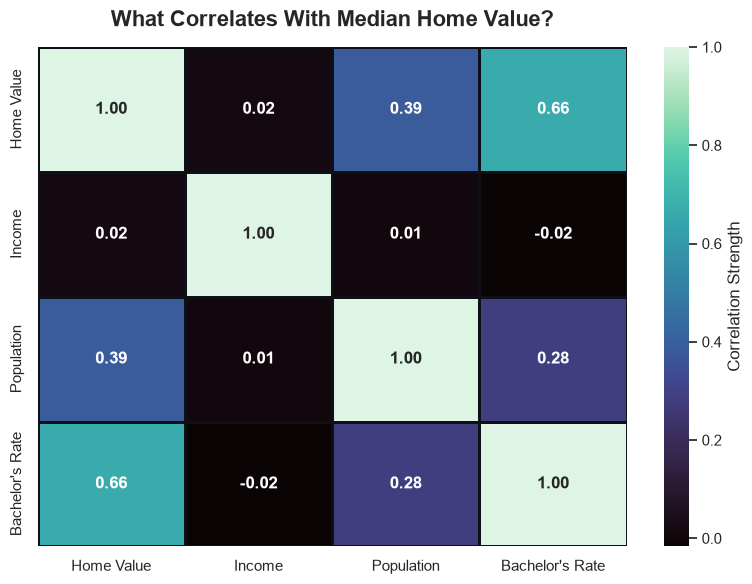

In [6]:
corr_cols = ["Median_Home_Value", "Median_Income", "Total_Population", "Bachelors_Rate"]
labels = ["Home Value", "Income", "Population", "Bachelor's Rate"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))
ax = sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="mako", linewidths=1, linecolor=DARK_BG,
    xticklabels=labels, yticklabels=labels, annot_kws={"size": 12, "weight": "bold"},
    cbar_kws={"label": "Correlation Strength"}
)
ax.set_title("What Correlates With Median Home Value?", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("corr_heatmap.png", dpi=200, facecolor=DARK_BG)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

features = ["Median_Income", "Total_Population", "Bachelors_Rate"]
target = "Median_Home_Value"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {len(X_train)}, Testing rows: {len(X_test)}")

Training rows: 2572, Testing rows: 644


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train_scaled, y_train)
baseline_preds = baseline.predict(X_test_scaled)

baseline_rmse = mean_squared_error(y_test, baseline_preds) ** 0.5
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_r2 = r2_score(y_test, baseline_preds)

print(f"Baseline RMSE: {baseline_rmse:,.0f}")
print(f"Baseline MAE: {baseline_mae:,.0f}")
print(f"Baseline R2: {baseline_r2:.3f}")

Baseline RMSE: 139,133
Baseline MAE: 90,559
Baseline R2: -0.001


In [10]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

lr_rmse = mean_squared_error(y_test, lr_preds) ** 0.5
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression RMSE: {lr_rmse:,.0f}")
print(f"Linear Regression MAE: {lr_mae:,.0f}")
print(f"Linear Regression R2: {lr_r2:.3f}")

Linear Regression RMSE: 97,805
Linear Regression MAE: 60,804
Linear Regression R2: 0.505


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest RMSE: {rf_rmse:,.0f}")
print(f"Random Forest MAE: {rf_mae:,.0f}")
print(f"Random Forest R2: {rf_r2:.3f}")

Random Forest RMSE: 69,990
Random Forest MAE: 45,344
Random Forest R2: 0.747


               Model           RMSE           MAE        R2
0    Baseline (Mean)  139133.362050  90559.212687 -0.001199
1  Linear Regression   97805.339511  60803.931212  0.505253
2      Random Forest   69989.739752  45343.542276  0.746647


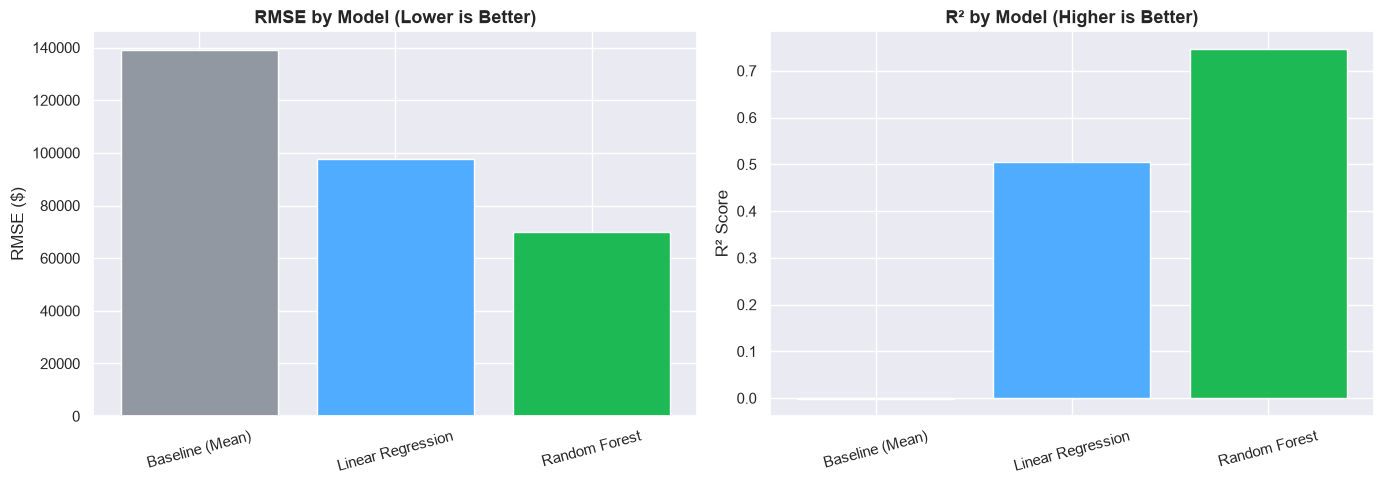

In [12]:
results = pd.DataFrame({
    "Model": ["Baseline (Mean)", "Linear Regression", "Random Forest"],
    "RMSE": [baseline_rmse, lr_rmse, rf_rmse],
    "MAE": [baseline_mae, lr_mae, rf_mae],
    "R2": [baseline_r2, lr_r2, rf_r2]
})
results.to_csv("model_comparison.csv", index=False)
print(results)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
colors = ["#9198a1", "#4FACFE", "#1DB954"]

axes[0].bar(results["Model"], results["RMSE"], color=colors)
axes[0].set_title("RMSE by Model (Lower is Better)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("RMSE ($)")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(results["Model"], results["R2"], color=colors)
axes[1].set_title("R² by Model (Higher is Better)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("R² Score")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=200, facecolor=DARK_BG)
plt.show()

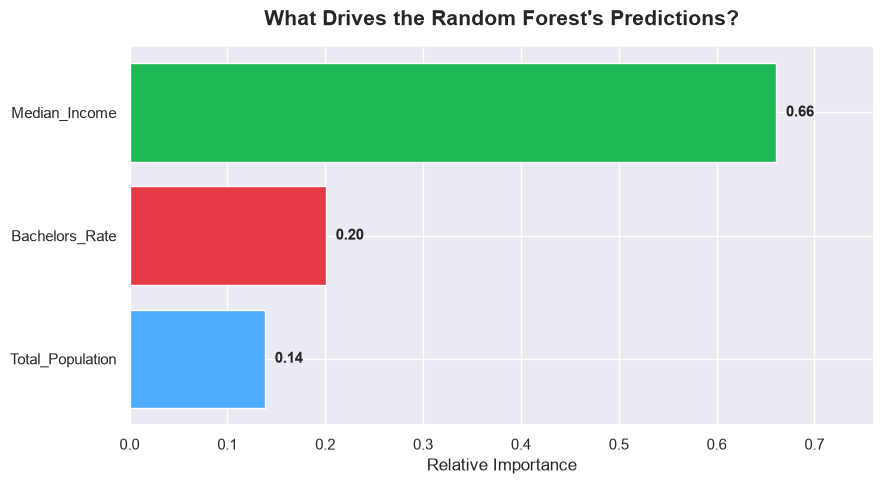

In [13]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9,5))
bars = plt.barh(importances.index, importances.values, color=["#4FACFE", "#E63946", "#1DB954"])
for bar, value in zip(bars, importances.values):
    plt.text(value + 0.01, bar.get_y() + bar.get_height()/2, f"{value:.2f}", va="center", fontsize=11, fontweight="bold")

plt.title("What Drives the Random Forest's Predictions?", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Relative Importance")
plt.xlim(0, max(importances.values) + 0.1)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=200, facecolor=DARK_BG)
plt.show()

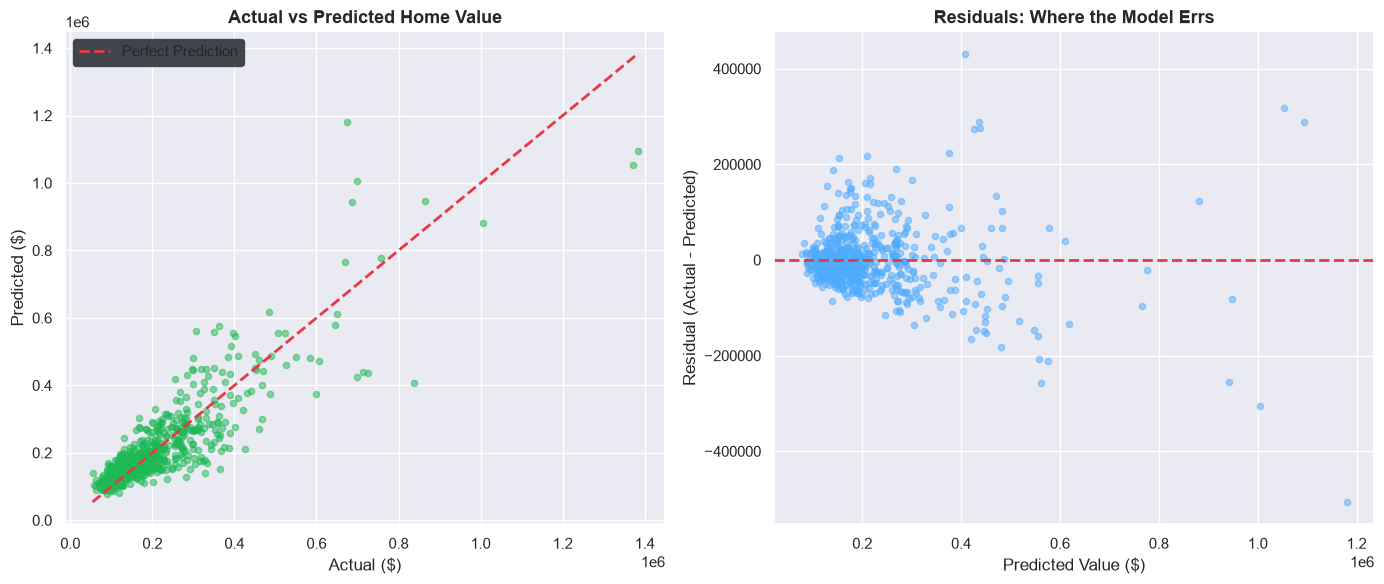

In [14]:
residuals = y_test - rf_preds

fig, axes = plt.subplots(1, 2, figsize=(14,6))

axes[0].scatter(y_test, rf_preds, alpha=0.5, color="#1DB954", s=20)
lims = [min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max())]
axes[0].plot(lims, lims, color="#E63946", linestyle="--", linewidth=2, label="Perfect Prediction")
axes[0].set_title("Actual vs Predicted Home Value", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Actual ($)")
axes[0].set_ylabel("Predicted ($)")
axes[0].legend()

axes[1].scatter(rf_preds, residuals, alpha=0.5, color="#4FACFE", s=20)
axes[1].axhline(0, color="#E63946", linestyle="--", linewidth=2)
axes[1].set_title("Residuals: Where the Model Errs", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted Value ($)")
axes[1].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=200, facecolor=DARK_BG)
plt.show()